# 06d - LIME Explanations
LIME (Local Interpretable Model-agnostic Explanations) generuje lidsky citelna pravidla pro konkretni predikce.
Na rozdil od SHAP je LIME model-agnostic — funguje stejne pro vsechny tri modely bez specialniho explaineru.

**Co ukazujeme:**
- LIME vysvetleni rizikoveho studenta pro vsechny 3 tuned modely
- Porovnani pravidel: shodi se vsechny modely na stejnych dulezitych faktorech?
- HTML vizualizace (interaktivni) + pyplot figure pro export

In [6]:
import lime
import lime.lime_tabular
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import joblib
from IPython.display import display, HTML

ctx = joblib.load('../results/xai/xai_context.pkl')
X_train_prep  = ctx['X_train_prep']
X_test_prep   = ctx['X_test_prep']
tuned_models  = ctx['tuned_models']
student_index = ctx['student_index']
risky_student = ctx['risky_student']
student_prob  = ctx['student_prob']
winning_name  = ctx['winning_name']

print(f"Rizikovy student: index {student_index}, predikce {student_prob:.1%}")

Rizikovy student: index 17, predikce 85.9%


## Inicializace LIME explaineru
Explainer inicializujeme jednou — pouzije se pro vsechny modely.

In [7]:
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_prep.values,
    feature_names=X_train_prep.columns.tolist(),
    class_names=['Dostuduje (0)', 'Dropout (1)'],
    mode='classification',
    random_state=42
)

def make_predict_fn(model):
    def predict_fn(data_matrix):
        df_temp = pd.DataFrame(data_matrix, columns=X_train_prep.columns)
        return model.predict_proba(df_temp)
    return predict_fn

print("LIME explainer inicializovan")

LIME explainer inicializovan


## LIME vysvětlení pro všechny 3 modely — rizikový student
Kazdý model interpretujeme zvlast, abychom videli, zda se shodnou na klicoavych faktorech.


  LIME: Logistic Regression — student c. 17 (85.9%)


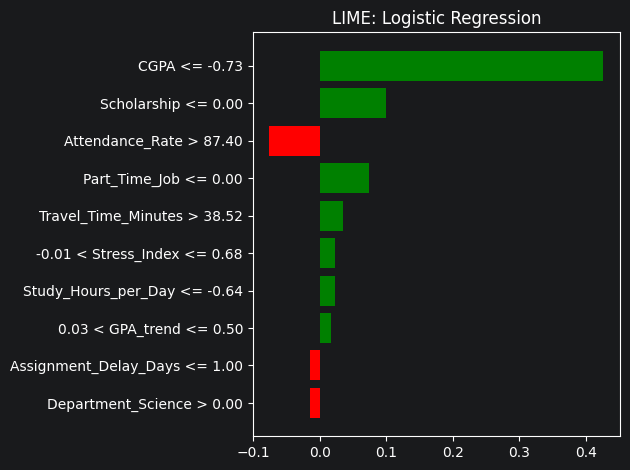


  LIME: Random Forest — student c. 17 (85.9%)


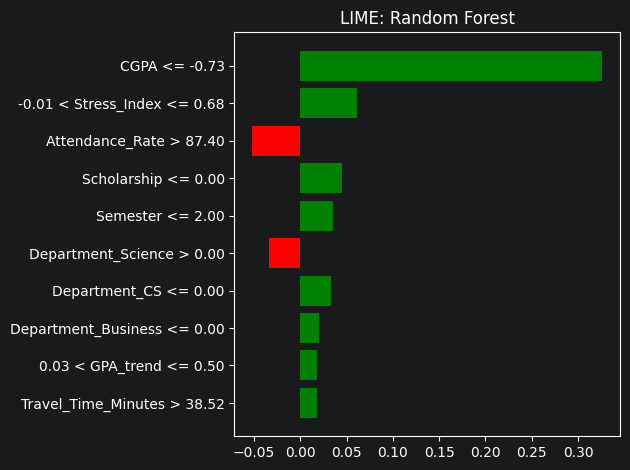


  LIME: Gradient Boosting — student c. 17 (85.9%)


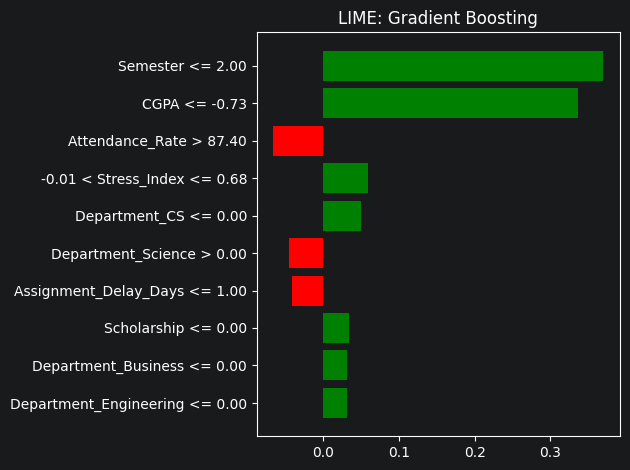

In [8]:
lime_explanations = {}

for name, model in tuned_models.items():
    print(f"\n{'=' * 55}")
    print(f"  LIME: {name} — student c. {student_index} ({student_prob:.1%})")
    print(f"{'=' * 55}")

    exp = lime_explainer.explain_instance(
        data_row=risky_student.values,
        predict_fn=make_predict_fn(model),
        num_features=10
    )

    lime_explanations[name] = exp

    # HTML vizualizace
    html_data = exp.as_html(show_table=True, show_all=False)
    display(HTML(html_data))

    # Pyplot figure pro archivaci
    exp.as_pyplot_figure()
    plt.title(f'LIME: {name}', fontsize=12)
    plt.tight_layout()
    plt.show()

## Srovnání LIME pravidel napříč modely
Extrahujeme vahu kazde featury z LIME a porovname, zda se modely shodnou.

In [9]:
rows = []
for name, exp in lime_explanations.items():
    for feat_label, weight in exp.as_list():
        rows.append({'Model': name, 'Pravidlo': feat_label, 'Vaha': weight})

df_lime = pd.DataFrame(rows)

# Serazeni podle absolutni vahy v ramci kazdeho modelu
print("Top-5 pravidel pro kazdy model:")
for name in tuned_models.keys():
    subset = df_lime[df_lime['Model'] == name].copy()
    subset['|Vaha|'] = subset['Vaha'].abs()
    print(f"\n  {name}:")
    print(subset.nlargest(5, '|Vaha|')[['Pravidlo', 'Vaha']].to_string(index=False))

Top-5 pravidel pro kazdy model:

  Logistic Regression:
                   Pravidlo      Vaha
              CGPA <= -0.73  0.426165
        Scholarship <= 0.00  0.099830
    Attendance_Rate > 87.40 -0.075782
      Part_Time_Job <= 0.00  0.073227
Travel_Time_Minutes > 38.52  0.035327

  Random Forest:
                    Pravidlo      Vaha
               CGPA <= -0.73  0.326522
-0.01 < Stress_Index <= 0.68  0.060678
     Attendance_Rate > 87.40 -0.052318
         Scholarship <= 0.00  0.044494
            Semester <= 2.00  0.034884

  Gradient Boosting:
                    Pravidlo      Vaha
            Semester <= 2.00  0.370308
               CGPA <= -0.73  0.336160
     Attendance_Rate > 87.40 -0.065868
-0.01 < Stress_Index <= 0.68  0.058722
       Department_CS <= 0.00  0.050211


## LIME pro bezpečného studenta (nejnižší riziko) — vítězný model
Kontrolni pripad: co model vidi jako ochranné faktory.

Bezpecny student: index 6, predikce 4.2%


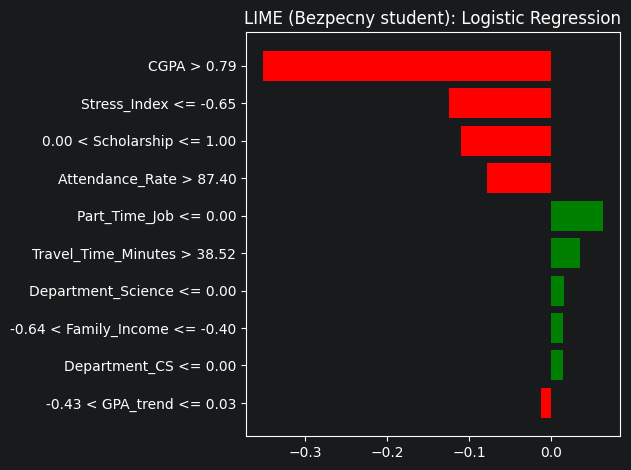

In [10]:
import joblib
ctx          = joblib.load('../results/xai/xai_context.pkl')
probabilities = ctx['probabilities']

safe_index = [i for i, p in enumerate(probabilities) if p < 0.10][0]
safe_prob  = probabilities[safe_index]
safe_student = X_test_prep.iloc[safe_index]

print(f"Bezpecny student: index {safe_index}, predikce {safe_prob:.1%}")

exp_safe = lime_explainer.explain_instance(
    data_row=safe_student.values,
    predict_fn=make_predict_fn(tuned_models[winning_name]),
    num_features=10
)

display(HTML(exp_safe.as_html(show_table=True, show_all=False)))
exp_safe.as_pyplot_figure()
plt.title(f'LIME (Bezpecny student): {winning_name}', fontsize=12)
plt.tight_layout()
plt.show()